In [1]:
import fastparquet as fp
import numpy as np
import matplotlib.pyplot as plt
import pathlib

from scipy.interpolate import Rbf

import utils.make_paths_absolute
from utils.loading_energy_mappings import load_energy_mappings

In [2]:
largest_examples = list(pathlib.Path("intermediates/energy_mappings/energies/too_large").glob("*.json"))
largest_examples = {file.stem: file for file in largest_examples}
for name in largest_examples:
    one_body, two_body = load_energy_mappings(largest_examples[name])
    largest_examples[name] = {"one_body": one_body, "two_body": two_body}

In [3]:
first_energy_record = largest_examples["5PTI_15_21_6"]
one_body, two_body = first_energy_record["one_body"], first_energy_record["two_body"]

In [4]:
def create_energy_matrix(one_body, two_body):
    """
    Maps one-body and two-body energies to a matrix suitable for surface plotting.

    Args:
        one_body: {residue_id: {rotamer_id: energy}}
        two_body: {(residue_i, residue_j): {(rotamer_i, rotamer_j): energy}}

    Returns:
        matrix: 2D numpy array where indices represent (residue, rotamer) combinations
        index_to_key: mapping from matrix index back to (residue_id, rotamer_id)
    """

    # Step 1: Create a mapping of all (residue, rotamer) combinations to flat indices
    flat_indices = {}
    index_to_key = {}
    current_idx = 0

    # Sort residues for consistent ordering
    for res_id in sorted(one_body.keys()):
        num_rotamers = len(one_body[res_id])
        for rot_id in range(num_rotamers):
            flat_indices[(res_id, rot_id)] = current_idx
            index_to_key[current_idx] = (res_id, rot_id)
            current_idx += 1

    total_elements = current_idx

    # Step 2: Create the energy matrix
    energy_matrix = np.full((total_elements, total_elements), np.nan)

    # Step 3: Fill in one-body energies (diagonal)
    for res_id, rotamers in one_body.items():
        for rot_id, energy in rotamers.items():
            idx = flat_indices[(res_id, rot_id)]
            energy_matrix[idx, idx] = energy

    # Step 4: Fill in two-body energies (off-diagonal)
    for (res_i, res_j), interactions in two_body.items():
        for (rot_i, rot_j), energy in interactions.items():
            idx_i = flat_indices[(res_i, rot_i)]
            idx_j = flat_indices[(res_j, rot_j)]

            # Store symmetrically (since it's an interaction)
            energy_matrix[idx_i, idx_j] = energy
            energy_matrix[idx_j, idx_i] = energy

    return energy_matrix, index_to_key, flat_indices

In [5]:
energy_matrix, index_to_key, flat_indices = create_energy_matrix(one_body, two_body)

In [6]:

def shift_and_log_data(energy_matrix):
    """
    Shifts energy data so all values are positive, then applies log scaling.
    Handles NaN values appropriately.

    Args:
        energy_matrix: 2D array with possibly negative values and NaNs

    Returns:
        log_matrix: Log-scaled matrix with all positive values
        shift_amount: Amount added to make data positive
    """
    # Find minimum value (ignoring NaN)
    min_val = np.nanmin(energy_matrix)

    # Shift so minimum is slightly above 0
    # Add 1 to ensure log(1) = 0 for the minimum value
    shift_amount = abs(min_val) + 1 if min_val < 0 else 1

    # Create shifted matrix
    shifted_matrix = energy_matrix + shift_amount

    # Apply log scale (NaN values remain NaN)
    log_matrix = np.log10(shifted_matrix)

    print(f"Data shifted by: {shift_amount}")
    print(f"Original range: [{np.nanmin(energy_matrix):.4f}, {np.nanmax(energy_matrix):.4f}]")
    print(f"Shifted range: [{np.nanmin(shifted_matrix):.4f}, {np.nanmax(shifted_matrix):.4f}]")
    print(f"Log range: [{np.nanmin(log_matrix):.4f}, {np.nanmax(log_matrix):.4f}]")

    return log_matrix, shift_amount


Data shifted by: 17.414934158325195
Original range: [-16.4149, 264.2562]
Shifted range: [1.0000, 281.6711]
Log range: [0.0000, 2.4497]
Figure saved to: outputs/plots/energy_landscape_sidechains_grey_gridlines2.svg


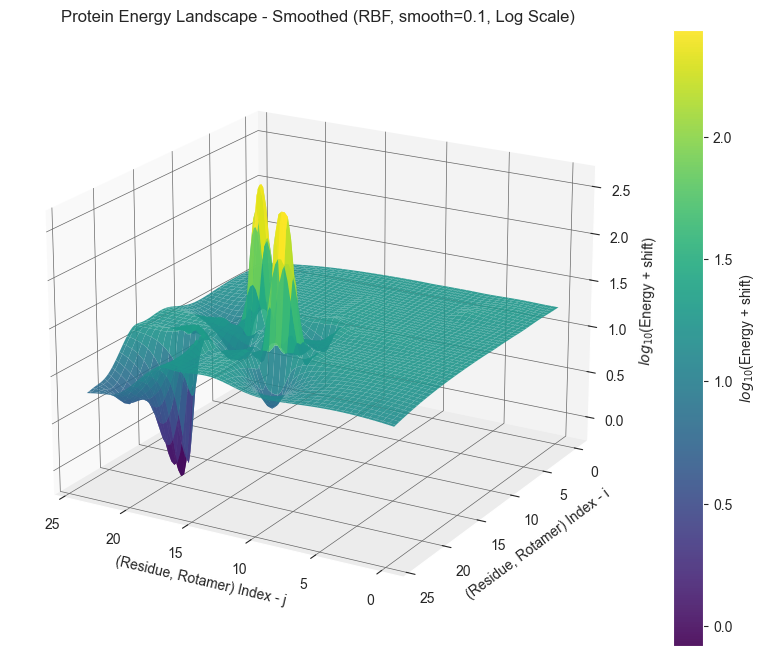

In [7]:
def plot_energy_landscape_triangulated_smooth_rbf_log_adjustable(
    energy_matrix,
    index_to_key,
    smooth=0.1,
    elev=30,
    azim=-60,
    save_path=None,
    dpi=300
):
    """
    Creates a smoothed 3D surface with log scaling using RBF interpolation.
    The outer background is transparent, and the 3D axis panes are slightly
    shaded with native gridlines for clean PDF embedding.
    """
    # Assuming this is a helper function you have defined elsewhere in your script
    log_matrix, shift_amount = shift_and_log_data(energy_matrix)

    # Extract valid (non-NaN) points
    valid_points = []
    valid_energies = []

    for i in range(log_matrix.shape[0]):
        for j in range(log_matrix.shape[1]):
            if not np.isnan(log_matrix[i, j]):
                valid_points.append([i, j])
                valid_energies.append(log_matrix[i, j])

    valid_points = np.array(valid_points)
    valid_energies = np.array(valid_energies)

    # Create RBF interpolator
    rbf = Rbf(valid_points[:, 0], valid_points[:, 1], valid_energies,
              function='thin_plate', smooth=smooth)

    # Create finer grid
    x_min, x_max = valid_points[:, 0].min(), valid_points[:, 0].max()
    y_min, y_max = valid_points[:, 1].min(), valid_points[:, 1].max()

    grid_x = np.linspace(x_min, x_max, 100)
    grid_y = np.linspace(y_min, y_max, 100)
    grid_X, grid_Y = np.meshgrid(grid_x, grid_y)

    grid_Z = rbf(grid_X, grid_Y)

    # Set up the figure and axis
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(grid_X, grid_Y, grid_Z, cmap='viridis', alpha=0.9,
                           edgecolor='none', antialiased=True)

    # Labels and titles
    ax.set_xlabel('(Residue, Rotamer) Index - j')
    ax.set_ylabel('(Residue, Rotamer) Index - i')
    ax.set_zlabel('$log_{10}$(Energy + shift)')
    ax.set_title(f'Protein Energy Landscape - Smoothed (RBF, smooth={smooth}, Log Scale)')

    # Set viewing angle
    ax.view_init(elev=elev, azim=azim)
    fig.colorbar(surf, ax=ax, label='$log_{10}$(Energy + shift)')

    # --- Cleaner Background and Grid Configuration ---

    # 1. Make the outer figure background completely transparent
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')

    # 2. Shade the 3D panes (the walls of the cube) slightly
    # Format is (Red, Green, Blue, Alpha transparency)
    ax.xaxis.pane.set_facecolor((0.96, 0.96, 0.96, 0.7))  # Lightest wall (simulated light hit)
    ax.yaxis.pane.set_facecolor((0.91, 0.91, 0.91, 0.7))  # Mid-tone wall (subtle shadow)
    ax.zaxis.pane.set_facecolor((0.86, 0.86, 0.86, 0.7))  # Darkest pane (the floor)

    # 3. Remove the thick dark borders around the edges of the panes
    ax.xaxis.pane.set_edgecolor('none')
    ax.yaxis.pane.set_edgecolor('none')
    ax.zaxis.pane.set_edgecolor('none')

    # 4. Turn on the native grid and make the lines white for a modern, clean look
    dark_grey = "#666666"
    ax.grid(True)
    ax.xaxis._axinfo["grid"].update({"color": dark_grey, "linewidth": 0.5})
    ax.yaxis._axinfo["grid"].update({"color": dark_grey, "linewidth": 0.5})
    ax.zaxis._axinfo["grid"].update({"color": dark_grey, "linewidth": 0.5})

    # Save figure if path provided
    if save_path:
        # bbox_inches='tight' removes excess padding around the image
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', transparent=True)
        print(f"Figure saved to: {save_path}")

    return fig, ax

# Usage with visible grid lines
fig1, ax1 = plot_energy_landscape_triangulated_smooth_rbf_log_adjustable(
    energy_matrix,
    index_to_key,
    smooth=0.1,
    elev=20,
    azim=120,
    save_path='outputs/plots/energy_landscape_sidechains_grey_gridlines2.svg',
)
plt.show()